# Peak Exploration Analysis — Phase 2 (Read-Only)

**Experiment 3 in the Module 1 research sequence.** Load and present the frozen Peak-Aware Hybrid **Phase 2** exploration: peak frequency, sequence structure, workload stratification, validation feasibility, and the **locked P90 peak definition**.

> **Scope:** Read-only view of `experiments/peak_exploration_2026-07-14/`.  
> No model training, no baseline modification, no rewriting of peak thresholds.  
> Original analyses were produced by `scripts/peak_exploration_task*.py`.  
> Docs: `docs/peak-aware-hybrid/phase-02-peak-exploration.md`.

## Research question

Which per-container percentile (P85 / P90 / P95) should define a CPU **peak** for Peak-Aware Hybrid learning?

## Kernel

Use `tf_metal_env` / `FYP_Long_Term`.

## 1. Configuration

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path("..").resolve()
EXP_DIR = REPO_ROOT / "experiments" / "peak_exploration_2026-07-14"
FIG_DIR = EXP_DIR / "figures"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

required = [
    EXP_DIR / "timestep_summary.csv",
    EXP_DIR / "sequence_peak_stats.csv",
    EXP_DIR / "threshold_comparison.csv",
    EXP_DIR / "workload_stratification.csv",
    EXP_DIR / "val_sanity_check.csv",
    EXP_DIR / "peak_definition_decision.json",
    EXP_DIR / "near_idle_impact_summary.csv",
]

print("Experiment dir:", EXP_DIR.relative_to(REPO_ROOT))
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing frozen Phase 2 artefacts:\n" + "\n".join(str(p) for p in missing)
    )
print("All required frozen artefacts found.")

Experiment dir: experiments/peak_exploration_2026-07-14
All required frozen artefacts found.


## 2. Load frozen Phase 2 tables

In [2]:
timestep_summary = pd.read_csv(EXP_DIR / "timestep_summary.csv")
sequence_stats = pd.read_csv(EXP_DIR / "sequence_peak_stats.csv")
threshold_comparison = pd.read_csv(EXP_DIR / "threshold_comparison.csv")
workload = pd.read_csv(EXP_DIR / "workload_stratification.csv")
val_sanity = pd.read_csv(EXP_DIR / "val_sanity_check.csv")
near_idle = pd.read_csv(EXP_DIR / "near_idle_impact_summary.csv")
per_container = pd.read_csv(EXP_DIR / "per_container_peak_stats.csv")

with open(EXP_DIR / "peak_definition_decision.json") as handle:
    decision = json.load(handle)

print("Tables loaded.")
print(f"Per-container peak-stats rows: {len(per_container)}")
print(f"Locked percentile: P{decision['chosen_percentile']}")

Tables loaded.
Per-container peak-stats rows: 99
Locked percentile: P90


## 3. Task 2 — Peak timestep rates (train)

Global fraction of train timesteps labelled as peaks under P85 / P90 / P95.

Table — Train peak timestep summary


,percentile,global_peak_timestep_pct,mean_container_peak_pct,median_container_peak_pct,std_container_peak_pct,min_container_peak_pct,max_container_peak_pct,containers_with_zero_peaks
0,85,21.661,21.669,16.287,18.551,14.984,100.0,0
1,90,17.361,17.370,11.582,19.632,10.000,100.0,0
2,95,11.054,11.065,5.728,18.656,5.000,100.0,0


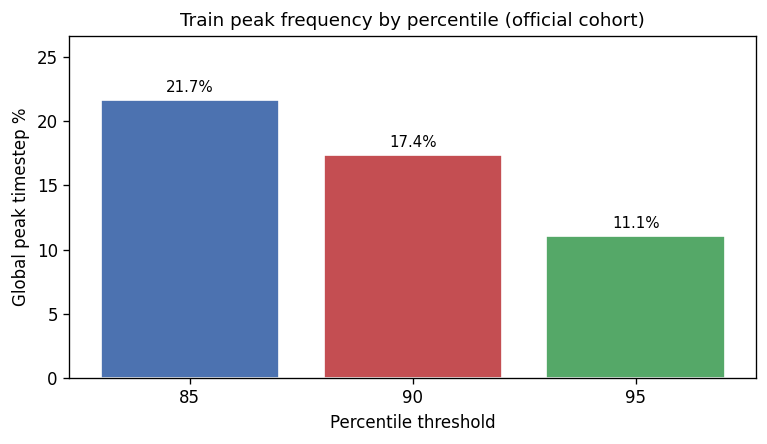

**Frozen figure:** `figures/task2_global_peak_timestep_rate.png`

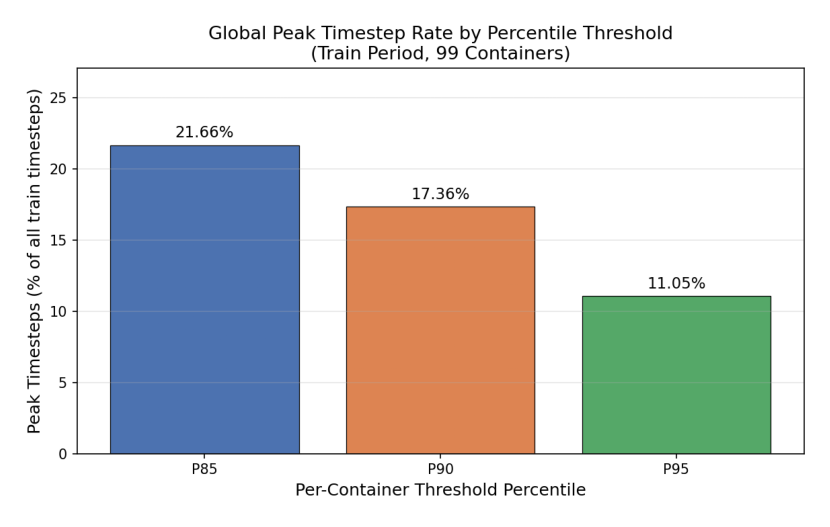

In [3]:
print("Table — Train peak timestep summary")
display(timestep_summary.round(3))

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.bar(
    timestep_summary["percentile"].astype(str),
    timestep_summary["global_peak_timestep_pct"],
    color=["#4C72B0", "#C44E52", "#55A868"],
    edgecolor="white",
)
ax.set_xlabel("Percentile threshold")
ax.set_ylabel("Global peak timestep %")
ax.set_title("Train peak frequency by percentile (official cohort)")
for x, y in zip(timestep_summary["percentile"].astype(str), timestep_summary["global_peak_timestep_pct"]):
    ax.text(x, y + 0.4, f"{y:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(timestep_summary["global_peak_timestep_pct"]) + 5)
fig.tight_layout()
plt.show()

# Show frozen figure if present
fig_path = FIG_DIR / "task2_global_peak_timestep_rate.png"
if fig_path.exists():
    display(Markdown("**Frozen figure:** `figures/task2_global_peak_timestep_rate.png`"))
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.imshow(img)
    ax.axis("off")
    fig.tight_layout()
    plt.show()

## 4. Near-idle containers (limitation)

Five near-idle containers have P90 threshold = 0, so every timestep is labelled a peak. This inflates global rates but was **not** used to change the locked definition.

In [4]:
print("Table — Near-idle impact summary")
display(near_idle.round(3))

idle_list = EXP_DIR / "near_idle_zero_threshold_containers.csv"
if idle_list.exists():
    idle_df = pd.read_csv(idle_list)
    print("\nNear-idle zero-threshold containers")
    display(idle_df.head(20))

Table — Near-idle impact summary


,percentile,original_global_peak_pct,adjusted_global_peak_pct_excluding_idle,change_percentage_points,idle_peak_timesteps,idle_share_of_all_peaks_pct
0,85,21.661,17.503,-4.158,3057,23.267
1,90,17.361,12.975,-4.386,3057,29.029
2,95,11.054,7.342,-3.712,2476,36.928



Near-idle zero-threshold containers


,container_id,pattern_type,cv,train_timesteps,threshold_p85,threshold_p90,threshold_p95,mean_cpu_real,max_cpu_real,peak_timesteps_p85,peak_timesteps_p90,peak_timesteps_p95
0,c_13308,spiky,33.196385,614,0.0,0.0,0.00,0.000407,0.250000,614,614,614
1,c_14106,spiky,23.547814,608,0.0,0.0,0.00,0.000548,0.333333,608,608,608
2,c_15035,spiky,23.441407,609,0.0,0.0,0.00,0.000616,0.250000,609,609,609
3,c_15446,spiky,7.364485,614,0.0,0.0,0.25,0.055646,5.000000,614,614,33
4,c_15794,spiky,23.679828,612,0.0,0.0,0.00,0.003813,2.333333,612,612,612


## 5. Task 3 — Sequence-level peaks (96→96)

If almost every sequence contains a peak, **sequence-level weighting** cannot discriminate; Phase 3 must use **timestep-level** weighting.

Table — Sequence peak statistics


,cohort,percentile,total_sequences,peak_sequences,peak_sequence_pct,mean_peak_timesteps_per_sequence,median_peak_timesteps_per_sequence,std_peak_timesteps_per_sequence,max_peak_timesteps_per_sequence,zero_peak_sequences,full_peak_sequences
0,official_all_containers,85,41650,40247,96.631,20.318,17.0,19.210,96,1403,2097
1,official_all_containers,90,41650,40065,96.194,16.259,12.0,19.680,96,1585,2097
2,official_all_containers,95,41650,38429,92.267,10.546,6.0,18.285,96,3221,1675


**Frozen figure:** `figures/task3_peak_sequence_rate.png`

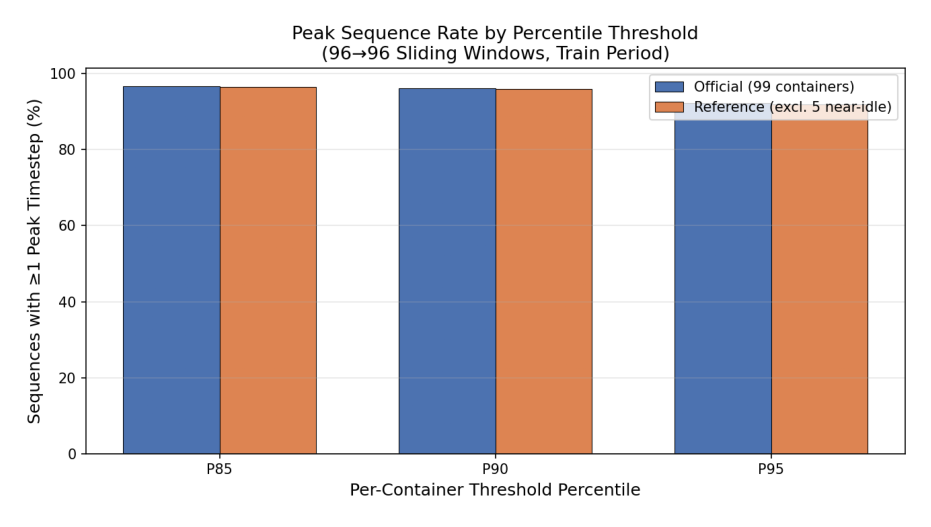


P90 sequence row:


,cohort,percentile,total_sequences,peak_sequences,peak_sequence_pct,mean_peak_timesteps_per_sequence,median_peak_timesteps_per_sequence,std_peak_timesteps_per_sequence,max_peak_timesteps_per_sequence,zero_peak_sequences,full_peak_sequences
1,official_all_containers,90,41650,40065,96.194478,16.25892,12.0,19.679605,96,1585,2097


In [5]:
print("Table — Sequence peak statistics")
display(sequence_stats.round(3))

fig_path = FIG_DIR / "task3_peak_sequence_rate.png"
if fig_path.exists():
    display(Markdown("**Frozen figure:** `figures/task3_peak_sequence_rate.png`"))
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.imshow(img)
    ax.axis("off")
    fig.tight_layout()
    plt.show()

p90_seq = sequence_stats.loc[sequence_stats["percentile"] == 90]
if not p90_seq.empty:
    row = p90_seq.iloc[0]
    # column names may vary; print available P90 row
    print("\nP90 sequence row:")
    display(row.to_frame().T.round(3))

## 6. Task 4 — Workload stratification

Peak rates by `pattern_type` (stable / medium / spiky). Spiky elevation is partly an artefact of near-idle containers.

Table — Workload stratification


,cohort,analysis_level,percentile,pattern_type,container_count,train_timesteps,weighted_peak_timestep_pct,mean_peak_timestep_pct,median_peak_timestep_pct,mean_threshold,mean_cpu_real,mean_cv,total_sequences,weighted_peak_sequence_pct,mean_peak_sequence_pct,weighted_mean_peak_steps_per_sequence,mean_peak_steps_per_sequence
0,official_all_containers,timestep,85,stable,35,21445.0,17.020,17.018,16.150,12.616,10.341,0.259,NaN,NaN,NaN,NaN,NaN
1,official_all_containers,timestep,85,medium,33,20224.0,17.657,17.656,15.961,15.037,11.101,0.395,NaN,NaN,NaN,NaN,NaN
2,official_all_containers,timestep,85,spiky,31,18989.0,31.165,31.191,17.676,8.729,5.383,4.365,NaN,NaN,NaN,NaN,NaN
3,official_all_containers,timestep,90,stable,35,21445.0,12.628,12.626,11.726,13.079,10.341,0.259,NaN,NaN,NaN,NaN,NaN
4,official_all_containers,timestep,90,medium,33,20224.0,12.030,12.029,10.984,15.783,11.101,0.395,NaN,NaN,NaN,NaN,NaN
5,official_all_containers,timestep,90,spiky,31,18989.0,28.385,28.413,14.332,9.737,5.383,4.365,NaN,NaN,NaN,NaN,NaN
6,official_all_containers,timestep,95,stable,35,21445.0,6.943,6.941,6.189,13.827,10.341,0.259,NaN,NaN,NaN,NaN,NaN
7,official_all_containers,timestep,95,medium,33,20224.0,7.145,7.143,5.375,16.811,11.101,0.395,NaN,NaN,NaN,NaN,NaN
8,official_all_containers,timestep,95,spiky,31,18989.0,19.859,19.894,6.209,11.782,5.383,4.365,NaN,NaN,NaN,NaN,NaN
9,official_all_containers,sequence,85,stable,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14725.0,98.316,98.298,16.072,16.061


**Frozen figure:** `figures/task4_peak_timestep_by_workload_official.png`

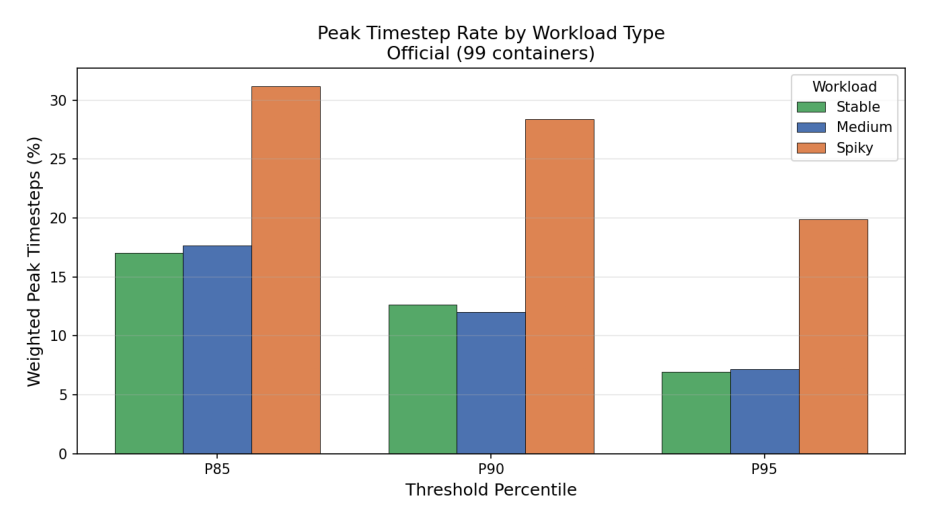

In [6]:
print("Table — Workload stratification")
display(workload.round(3))

fig_path = FIG_DIR / "task4_peak_timestep_by_workload_official.png"
if fig_path.exists():
    display(Markdown("**Frozen figure:** `figures/task4_peak_timestep_by_workload_official.png`"))
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.imshow(img)
    ax.axis("off")
    fig.tight_layout()
    plt.show()

## 7. Task 5 — Validation feasibility

Train-fitted thresholds applied to validation (no tuning). Confirms Day-1 peak-subset metrics will be measurable in Phase 5.

Table — Validation sanity check


,cohort,percentile,train_peak_timestep_pct,val_peak_timestep_pct,train_val_timestep_ratio,train_total_sequences,val_sliding_sequences,train_peak_sequence_pct,val_sliding_peak_sequence_pct,val_day1_containers_with_peak_pct,val_day1_peak_timestep_pct,val_sliding_sequences_feasible,val_peak_evaluation_feasible
0,official_all_containers,85,21.661,33.912,1.566,41650,0,96.631,0.0,98.990,30.745,0,1
1,official_all_containers,90,17.361,28.294,1.630,41650,0,96.194,0.0,98.990,25.652,0,1
2,official_all_containers,95,11.054,19.449,1.760,41650,0,92.267,0.0,97.980,17.466,0,1
3,reference_excl_near_idle,85,21.661,30.399,1.403,41650,0,96.631,0.0,98.936,27.061,0,1
4,reference_excl_near_idle,90,17.361,24.483,1.410,41650,0,96.194,0.0,98.936,21.698,0,1
5,reference_excl_near_idle,95,11.054,16.151,1.461,41650,0,92.267,0.0,97.872,14.096,0,1



Table — Day-1 horizon peak feasibility


,container_id,val_timesteps_in_horizon,day1_peak_steps_p85,day1_has_peak_p85,day1_peak_steps_p90,day1_has_peak_p90,day1_peak_steps_p95,day1_has_peak_p95,cohort
0,c_10032,96,19,1,18,1,18,1,official_all_containers
1,c_10034,96,0,0,0,0,0,0,official_all_containers
2,c_10089,96,30,1,19,1,14,1,official_all_containers
3,c_10132,96,15,1,15,1,2,1,official_all_containers
4,c_1016,96,19,1,8,1,8,1,official_all_containers
...,...,...,...,...,...,...,...,...,...
188,c_15642,96,17,1,17,1,1,1,reference_excl_near_idle
189,c_15647,96,15,1,5,1,2,1,reference_excl_near_idle
190,c_15856,96,29,1,29,1,15,1,reference_excl_near_idle
191,c_16008,96,70,1,70,1,68,1,reference_excl_near_idle


**Frozen figure:** `figures/task5_train_vs_val_peak_timestep_official.png`

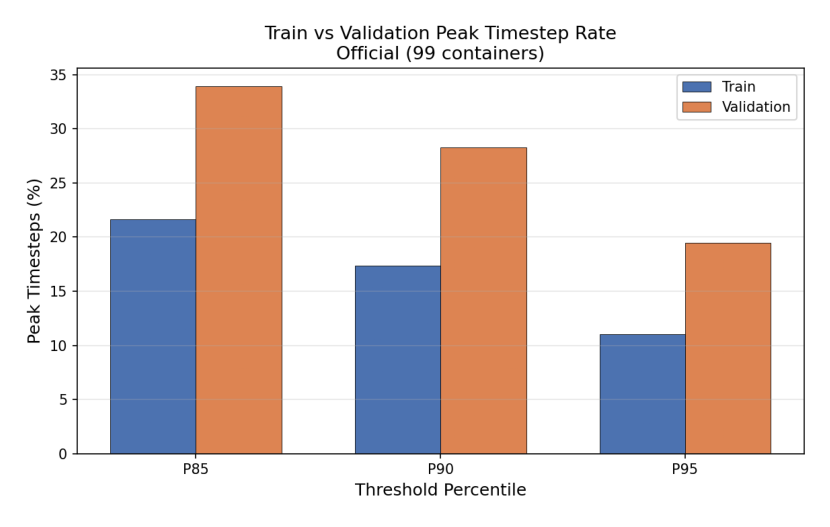

In [7]:
print("Table — Validation sanity check")
display(val_sanity.round(3))

day1_path = EXP_DIR / "val_day1_horizon_sanity.csv"
if day1_path.exists():
    print("\nTable — Day-1 horizon peak feasibility")
    display(pd.read_csv(day1_path).round(3))

fig_path = FIG_DIR / "task5_train_vs_val_peak_timestep_official.png"
if fig_path.exists():
    display(Markdown("**Frozen figure:** `figures/task5_train_vs_val_peak_timestep_official.png`"))
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.imshow(img)
    ax.axis("off")
    fig.tight_layout()
    plt.show()

## 8. Task 6 — Threshold comparison (P85 vs P90 vs P95)

Table — Consolidated threshold comparison


,percentile,train_peak_timestep_pct,train_peak_timestep_pct_reference_excl_idle,train_peak_sequence_pct,train_zero_peak_sequence_pct,train_mean_peak_steps_per_sequence,train_mean_peak_steps_reference_excl_idle,mean_peak_pct_stable,mean_peak_pct_medium,mean_peak_pct_spiky,val_peak_timestep_pct,val_day1_peak_timestep_pct,val_day1_containers_with_peak_pct,val_peak_evaluation_feasible,near_idle_share_of_train_peaks_pct,summary_notes
0,85,21.661,17.503,96.631,3.369,20.318,16.306,17.020,17.657,31.165,33.912,30.745,98.99,1,23.267,Loosest threshold; highest peak rates; limited...
1,90,17.361,12.975,96.194,3.806,16.259,12.031,12.628,12.030,28.385,28.294,25.652,98.99,1,29.029,Balanced candidate; ~17% train / ~28% val peak...
2,95,11.054,7.342,92.267,7.733,10.546,6.976,6.943,7.145,19.859,19.449,17.466,97.98,1,36.928,Strictest threshold; lowest peak rates (~11% t...


**Frozen figure:** `figures/task6_threshold_comparison.png`

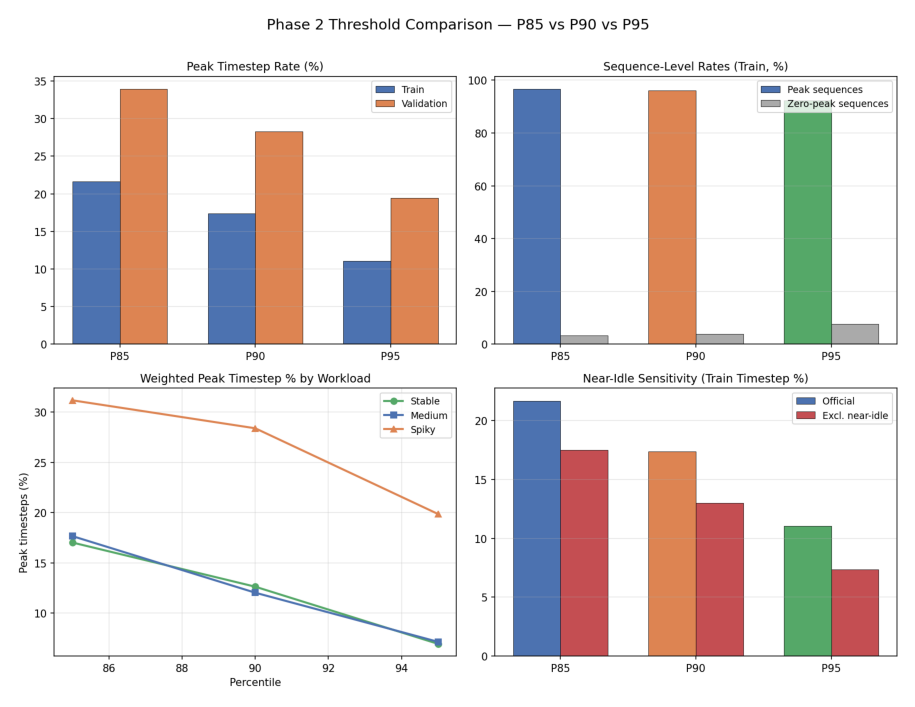

In [8]:
print("Table — Consolidated threshold comparison")
display(threshold_comparison.round(3))

fig_path = FIG_DIR / "task6_threshold_comparison.png"
if fig_path.exists():
    display(Markdown("**Frozen figure:** `figures/task6_threshold_comparison.png`"))
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img)
    ax.axis("off")
    fig.tight_layout()
    plt.show()

## 9. Task 7 — Locked peak definition (decision)

In [9]:
peak_def = decision["peak_definition"]
train_c = decision["expected_train_characteristics"]
val_c = decision["expected_validation_characteristics"]
p3 = decision["phase_3_recommendations"]

print("=" * 72)
print("LOCKED PEAK DEFINITION")
print("=" * 72)
print(peak_def["rule"])
print(f"Chosen percentile     : P{decision['chosen_percentile']}")
print(f"Value space           : {peak_def['value_space']}")
print(f"Threshold scope       : {peak_def['threshold_scope']}")
print(f"Fit period            : {peak_def['threshold_fit_period']}")
print(f"Absolute CPU floor    : {peak_def.get('absolute_cpu_floor_applied', False)}")
print(f"Locked for remainder  : {decision.get('locked_for_remainder_of_research', True)}")

print("\nExpected characteristics under P90")
char_df = pd.DataFrame([
    {"split": "train", "metric": "peak timestep %", "value": train_c["train_peak_timestep_pct"]},
    {"split": "train", "metric": "peak sequence %", "value": train_c["train_peak_sequence_pct"]},
    {"split": "train", "metric": "zero-peak sequence %", "value": train_c["train_zero_peak_sequence_pct"]},
    {"split": "train", "metric": "mean peak steps / sequence", "value": train_c["train_mean_peak_steps_per_sequence"]},
    {"split": "val", "metric": "peak timestep %", "value": val_c["val_peak_timestep_pct"]},
    {"split": "val", "metric": "Day-1 peak timestep %", "value": val_c["val_day1_peak_timestep_pct"]},
    {"split": "val", "metric": "Day-1 containers with ≥1 peak %", "value": val_c["val_day1_containers_with_peak_pct"]},
])
display(char_df)

print("\nRejected alternatives")
display(pd.DataFrame(decision["rejected_alternatives"]))

print("\nPhase 3 recommendations from this decision")
for k, v in p3.items():
    print(f"  - {k}: {v}")

print("\nKnown limitations")
for item in decision.get("known_limitations", []):
    print(f"  - {item}")

LOCKED PEAK DEFINITION
A timestep is a peak if cpu_real >= P90(container_train)
Chosen percentile     : P90
Value space           : real_cpu_percent
Threshold scope       : per_container
Fit period            : train_only
Absolute CPU floor    : False
Locked for remainder  : True

Expected characteristics under P90


,split,metric,value
0,train,peak timestep %,17.36
1,train,peak sequence %,96.19
2,train,zero-peak sequence %,3.81
3,train,mean peak steps / sequence,16.26
4,val,peak timestep %,28.29
5,val,Day-1 peak timestep %,25.65
6,val,Day-1 containers with ≥1 peak %,98.99



Rejected alternatives


,percentile,reason,method
0,85.0,Too permissive (~22% train peak timesteps); we...,NaN
1,95.0,Conservative (~11% train peaks); may under-emp...,NaN
2,NaN,Not adopted; Phase 2 exploration showed near-i...,absolute_cpu_floor
3,NaN,Rejected; per-container MinMax scaling makes g...,global_threshold
4,NaN,Rejected for Phase 3; >92% of sequences are pe...,sequence_level_weighting



Phase 3 recommendations from this decision
  - weighting_granularity: timestep_weighted_mse
  - early_stopping: unweighted_val_loss_unchanged_from_baseline
  - lambda: to_be_justified_in_phase_3_design_simple_fixed_or_small_set
  - suggested_starting_lambda: 5

Known limitations
  - Five near-idle containers have zero thresholds, inflating peak labels (~29% of train peak timesteps at P90)
  - Spiky workload label partially reflects near-idle CV artefact
  - Validation peak rates exceed train rates under fixed thresholds (distribution shift)
  - Short train history (~614 steps/container) makes percentile estimates coarse for low-activity containers


## 10. Key findings & results (viva summary)

In [10]:
p90_train = float(train_c["train_peak_timestep_pct"])
p90_seq = float(train_c["train_peak_sequence_pct"])
p90_val_day1 = float(val_c["val_day1_peak_timestep_pct"])

findings = pd.DataFrame([
    {
        "finding": "Train peak rates (P85 / P90 / P95)",
        "result": "~22% / ~17% / ~11% of timesteps",
    },
    {
        "finding": "P85 too loose; P95 too strict",
        "result": "P90 chosen as balanced peak label",
    },
    {
        "finding": "Peak sequences at P90",
        "result": f"~{p90_seq:.1f}% of 96→96 sequences contain ≥1 peak",
    },
    {
        "finding": "Weighting granularity for Phase 3",
        "result": "Timestep-weighted MSE (not sequence-level)",
    },
    {
        "finding": "Near-idle limitation",
        "result": "5/99 containers with zero P90 threshold; floor not applied",
    },
    {
        "finding": "Validation feasibility (P90)",
        "result": f"Day-1 peak timesteps ~{p90_val_day1:.1f}%; ~99% containers have ≥1 peak",
    },
    {
        "finding": "Locked definition",
        "result": peak_def["rule"],
    },
])

print("Table — Key findings and results")
display(findings)

print("\n" + "=" * 72)
print("KEY FINDING")
print("=" * 72)
print(
    "Phase 2 locked the Peak-Aware peak label to per-container train-only P90 on "
    f"real CPU % (~{p90_train:.1f}% of train timesteps). Because ~{p90_seq:.0f}% of "
    "training sequences contain at least one peak, sequence-level weighting is "
    "ineffective; Phase 3 must use timestep-weighted MSE. No forecasting model "
    "was trained in this experiment."
)
print("=" * 72)

Table — Key findings and results


,finding,result
0,Train peak rates (P85 / P90 / P95),~22% / ~17% / ~11% of timesteps
1,P85 too loose; P95 too strict,P90 chosen as balanced peak label
2,Peak sequences at P90,~96.2% of 96→96 sequences contain ≥1 peak
3,Weighting granularity for Phase 3,Timestep-weighted MSE (not sequence-level)
4,Near-idle limitation,5/99 containers with zero P90 threshold; floor...
5,Validation feasibility (P90),Day-1 peak timesteps ~25.6%; ~99% containers h...
6,Locked definition,A timestep is a peak if cpu_real >= P90(contai...



KEY FINDING
Phase 2 locked the Peak-Aware peak label to per-container train-only P90 on real CPU % (~17.4% of train timesteps). Because ~96% of training sequences contain at least one peak, sequence-level weighting is ineffective; Phase 3 must use timestep-weighted MSE. No forecasting model was trained in this experiment.


## 11. References

| Item | Path |
|------|------|
| Frozen experiment | `experiments/peak_exploration_2026-07-14/` |
| Decision markdown | `experiments/peak_exploration_2026-07-14/peak_definition_decision.md` |
| Research log | `docs/peak-aware-hybrid/phase-02-peak-exploration.md` |
| Scripts | `scripts/peak_exploration_task2_timesteps.py` … `task6_*.py` |
| Next (model comparison notebook) | `notebooks/peak_aware_container_comparison.ipynb` (Phase 5/6, not this exploration) |
| Prior control | `experiments/baseline_reference_2026-07-14/` |